# Experiment 4: EfficientNet

#### Add dependencies

In [2]:
import tensorflow as tf
import numpy as np
import cv2

### Load Processed Dataset

In [6]:
import src.ImagesPreprocessorService

In [7]:
( complete_dataset, training_dataset, validation_dataset, testing_dataset) = src.ImagesPreprocessorService.load_processed_dataset()
(X_train, y_train, X_val, y_val, X_test, y_test) = src.ImagesPreprocessorService.get_labeled_datasets(training_dataset, validation_dataset, testing_dataset)

### Constructing Tensorflow Datasets
##### We can load the cropped and pre-split images under processed_data into three tf.data.Dataset instances. This is the data structure we'll need to use to contain the image tensors. We must group samples into batches, and enable prefetching (paralellises CPU data loading and GPU model training).
##### For EfficienbtNet we will not normalise the dataset images as Tensorflow's EfficientNetB0 already has image normalization imbedded

In [4]:
def create_dataset(image_paths, labels, batch_size=32, shuffle=True):
    images = []

    for path in image_paths:
        image = load_image(path)
        images.append(image)

    images = np.array(images)
    labels = np.array(labels)

    dataset = tf.data.Dataset.from_tensor_slices((images, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(images))

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [3]:
def load_image(image_path):
    """
    Load preprocessed image.
    
    """

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise Exception(f"Could not load image: {image_path}")

    # Convert to float32
    image = image.astype(np.float32)

    # Add grayscale channel to expand dimensions to 244x244x3
    image = np.expand_dims(image, axis=-1)

    # Convert grayscale to RGB
    image = np.repeat(image, 3, axis=-1)

    return image

#### Set test, train and validation datasets

In [8]:
train = create_dataset( X_train, y_train)
val = create_dataset( X_val, y_val, shuffle=False)
test = create_dataset(X_test, y_test, shuffle=False)

### Model Construction and Training Loop
##### Here we construct the EfficientNet classifier. Please see model.py for implementation details.
##### The EfficientNetBinaryClassifier is a binary image classification model built using Tensorflow's EfficientNetB0 architecture and transfer learning. The model removes the original classification head of EfficientNetB0 and replaces it with custom layers consisting of global average pooling, dropout regularization, a fully connected dense layer with ReLU activation, and a sigmoid output layer for binary prediction.
##### Input images are first processed by the EfficientNet to extract high-level visual features, which are then transformed into compact feature vectors and classified into one of two classes. The model supports both frozen-backbone training and fine-tuning, making it suitable for efficient and accurate binary image classification tasks.

In [9]:
from src.models import EfficientNetBinaryClassifier

In [10]:
effNetModel = EfficientNetBinaryClassifier(train_backbone=False, dropout_rate=0.0)

effNetModel.build((None, 224, 224, 3))

effNetModel.summary()

Model: "efficient_net_binary_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  multiple                 0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           multiple                  0         
                                                                 
 dense (Dense)               multiple                  327936    
                                                                 
 dense_1 (Dense)             multiple                  257       
                                                                 
Total params: 4,377,764
Trainable params: 328,193
Non-trainable params: 4,049,571
___________________

In [11]:
effNetModel.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [49]:
from pathlib import Path

# Create callbacks
CHECKPOINT_DIR = Path(".") / "checkpoints" / "EfficientNetBinaryClassifier"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    CHECKPOINT_DIR / "efficientnet_epoch-{epoch:02d}.weights.h5",
    save_weights_only=True,
    save_best_only=False, # Save weights for every epoch
    monitor="val_loss",
    mode="min",
    verbose=1
)

# Set class weights in an attempt to make for data impalance between the two classes
class_weight = {
    0: 2.8,   # NORMAL
    1: 1.0    # PNEUMONIA
}

history = effNetModel.fit(train, validation_data=val, epochs=10, class_weight=class_weight, callbacks=[checkpoint_callback])

Epoch 1/10
147/148 [============================>.] - ETA: 0s - loss: 0.0626 - accuracy: 0.9821 - precision: 0.9968 - recall: 0.9791
Epoch 1: saving model to checkpoints\EfficientNetBinaryClassifier\efficientnet_epoch-01.weights.h5
148/148 [==============================] - 13s 84ms/step - loss: 0.0626 - accuracy: 0.9822 - precision: 0.9968 - recall: 0.9791 - val_loss: 0.0698 - val_accuracy: 0.9714 - val_precision: 0.9895 - val_recall: 0.9717
Epoch 2/10
147/148 [============================>.] - ETA: 0s - loss: 0.0635 - accuracy: 0.9828 - precision: 0.9965 - recall: 0.9802
Epoch 2: saving model to checkpoints\EfficientNetBinaryClassifier\efficientnet_epoch-02.weights.h5
148/148 [==============================] - 12s 84ms/step - loss: 0.0634 - accuracy: 0.9828 - precision: 0.9965 - recall: 0.9803 - val_loss: 0.0797 - val_accuracy: 0.9714 - val_precision: 0.9921 - val_recall: 0.9692
Epoch 3/10
147/148 [============================>.] - ETA: 0s - loss: 0.0551 - accuracy: 0.9851 - precisio

In [51]:
results = effNetModel.evaluate(test)

print(results)

20/20 [==============================] - 2s 72ms/step - loss: 0.5871 - accuracy: 0.8429 - precision: 0.8029 - recall: 0.9923
[0.5871220231056213, 0.8429487347602844, 0.8029046058654785, 0.992307722568512]


#### Training History
##### The fit method returns a history object which we can use to plot training and validation accuracies and losses through epochs. The dataset is quite small, and the validation set is especially so, which is why validation metrics are a little jumpy.

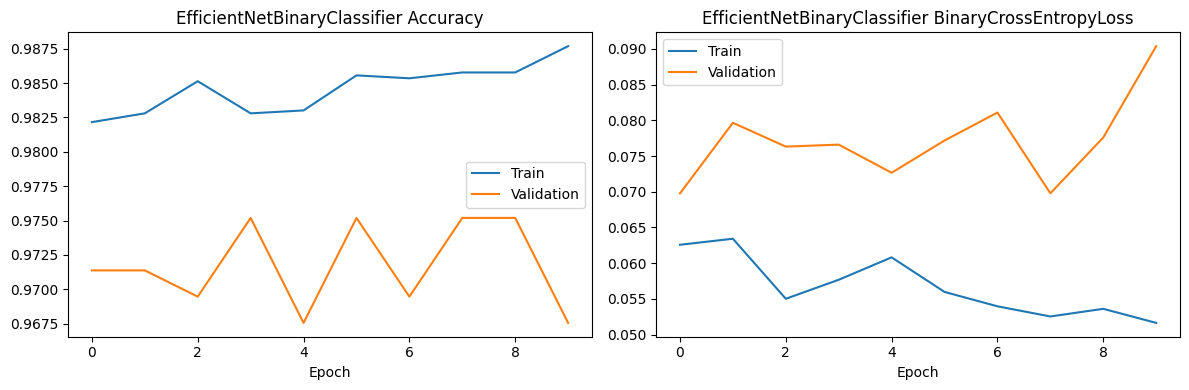

In [55]:
from pathlib import Path
from src.plot import plot_history

FIG_DIR = Path(".") / "outputs" / "EfficientNetBinaryClassifier"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_NAME = "EfficientNetBinaryClassifier"

plot_history(history, MODEL_NAME, FIG_DIR / "training_history.png")

## Evaluation

Run `Evaluation.ipynb`.